Detected CPU cores: 10

Running with 1 threads...
Threads=1, Time=0.08 min, CPU=20.0%

Running with 2 threads...
Threads=2, Time=0.05 min, CPU=7.3%

Running with 3 threads...
Threads=3, Time=0.05 min, CPU=31.8%

Running with 4 threads...
Threads=4, Time=0.05 min, CPU=11.8%

Running with 5 threads...
Threads=5, Time=0.05 min, CPU=7.0%

Running with 6 threads...
Threads=6, Time=0.05 min, CPU=9.0%

Running with 7 threads...
Threads=7, Time=0.05 min, CPU=2.1%

Running with 8 threads...
Threads=8, Time=0.05 min, CPU=5.2%

Running with 9 threads...
Threads=9, Time=0.05 min, CPU=5.0%

Running with 10 threads...
Threads=10, Time=0.05 min, CPU=15.8%

Running with 11 threads...
Threads=11, Time=0.05 min, CPU=9.4%

Running with 12 threads...
Threads=12, Time=0.05 min, CPU=5.7%

Running with 13 threads...
Threads=13, Time=0.05 min, CPU=6.8%

Running with 14 threads...
Threads=14, Time=0.05 min, CPU=7.9%

Running with 15 threads...
Threads=15, Time=0.05 min, CPU=12.6%

Running with 16 threads...
Th

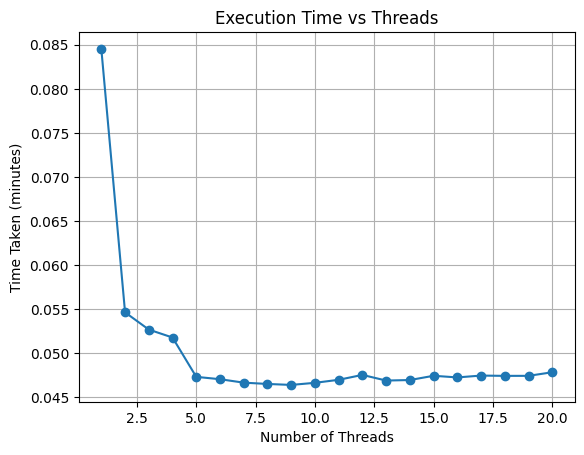

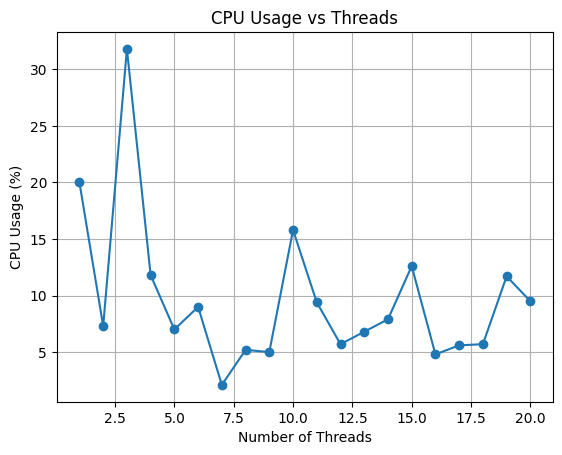

In [3]:
import numpy as np
import time
import os
import psutil
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

# -----------------------
# Config (SAFE values first)
# -----------------------
SIZE = 1000        # change to 5000 later
NUM_MATRICES = 500    # change to 500 later

# -----------------------
# Generate Data
# -----------------------
constant_matrix = np.random.rand(SIZE, SIZE)
matrices = [np.random.rand(SIZE, SIZE) for _ in range(NUM_MATRICES)]

# -----------------------
# Task Function
# -----------------------
def multiply(matrix):
    return np.dot(matrix, constant_matrix)

# -----------------------
# Run with threads
# -----------------------
def run_threads(thread_count):
    start_time = time.time()

    # Start CPU measurement
    psutil.cpu_percent(interval=None)

    with ThreadPoolExecutor(max_workers=thread_count) as executor:
        results = list(executor.map(multiply, matrices))

    # Measure CPU after execution
    cpu_usage = psutil.cpu_percent(interval=1)

    end_time = time.time()

    return (end_time - start_time) / 60, cpu_usage


# -----------------------
# Main Execution
# -----------------------
cores = os.cpu_count()
max_threads = 2 * cores

results_time = []
results_cpu = []
thread_list = []

print(f"Detected CPU cores: {cores}")

for t in range(1, max_threads + 1):
    print(f"\nRunning with {t} threads...")

    time_taken, cpu = run_threads(t)

    thread_list.append(t)
    results_time.append(time_taken)
    results_cpu.append(cpu)

    print(f"Threads={t}, Time={time_taken:.2f} min, CPU={cpu}%")

# -----------------------
# Graph 1: Threads vs Time
# -----------------------
plt.figure()
plt.plot(thread_list, results_time, marker='o')
plt.xlabel("Number of Threads")
plt.ylabel("Time Taken (minutes)")
plt.title("Execution Time vs Threads")
plt.grid()
plt.show()

# -----------------------
# Graph 2: Threads vs CPU Usage
# -----------------------
plt.figure()
plt.plot(thread_list, results_cpu, marker='o')
plt.xlabel("Number of Threads")
plt.ylabel("CPU Usage (%)")
plt.title("CPU Usage vs Threads")
plt.grid()
plt.show()